In [2]:
## Here we should be wroking on Computer Vision and Image Classification using Convolutional Neural Networks (CNNs)
import torchvision as trv
import torch as tr
from torch import nn
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

print(trv.__version__)



0.27.1+cu132


In [3]:
## Preparing data for Training

train_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download = True,
    transform  = trv.transforms.ToTensor(),
    target_transform = None

)
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform  = trv.transforms.ToTensor(),
    target_transform = None
)


In [4]:
len(train_data), len(test_data)

(60000, 10000)

In [5]:
image, label = train_data[0]
label, image

(9,
 tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.00

In [6]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [8]:
image.shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Ankle boot')

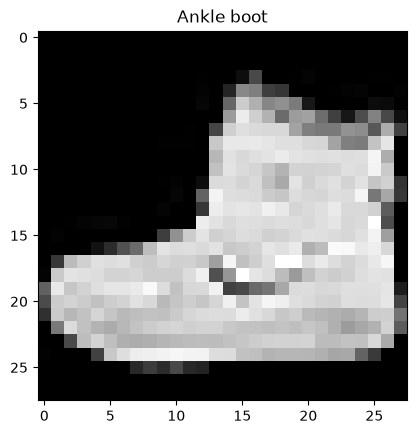

In [9]:
# visualize the model

image, label = train_data[0]
# print(image)
plt.imshow(image.squeeze())
plt.imshow(image.squeeze(), cmap= "gray")
plt.title(class_names[label])

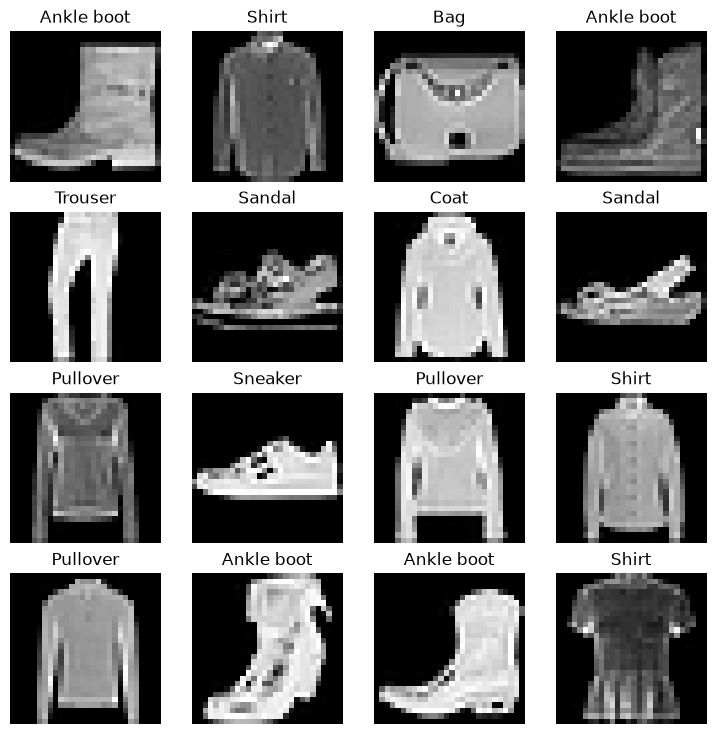

In [10]:
tr.manual_seed(42)
tr.cuda.manual_seed(42)

fig = plt.figure(figsize = (9,9))

rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = tr.randint(0, len(train_data), size = [1]).item()
    image, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(image.squeeze(), cmap = "gray")
    plt.title(class_names[label])
    plt.axis(False)


In [11]:
train_data, test_data



(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [12]:
# prepare dataloader


from torch.utils.data import DataLoader

batch_size = 32
train_dataloader = DataLoader(train_data, batch_size = batch_size, shuffle = True)
test_dataloader = DataLoader(test_data, batch_size = batch_size, shuffle = False)
train_dataloader, test_dataloader
len(train_dataloader), len(test_dataloader), batch_size

(1875, 313, 32)

In [13]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [14]:
##make a baseline model

flatten_model = nn.Flatten()

x= train_features_batch[0]

output = flatten_model(x)
output.shape, x.shape

(torch.Size([1, 784]), torch.Size([1, 28, 28]))

In [15]:
class Fashionmnistmodelv0(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.layer_stack  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape, out_features = hidden_units),
            nn.Linear(in_features = hidden_units, out_features = output_shape)
        )
    def forward(self, x):
        return self.layer_stack(x)


model_0 = Fashionmnistmodelv0(input_shape = 28*28, hidden_units = 10, output_shape = len(class_names))
model_0






Fashionmnistmodelv0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [16]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = tr.optim.SGD(params = model_0.parameters(), lr= 0.01)

In [17]:
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: tr.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [18]:
## creating a trainin l[p and training model on batches of data
from tqdm.auto import tqdm

device = "cuda" if tr.cuda.is_available() else "cpu"
tr.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")

    train_loss = 0

    for batch, (x, y) in enumerate(train_dataloader):
        model_0. train()
        y_pred = model_0(x)
        loss = loss_fn(y_pred, y)
        train_loss  += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(x)}/{len(train_dataloader.dataset)} samples.")

    train_loss /= len(train_dataloader)  

    test_loss, test_acc = 0, 0
    model_0.eval()
    with tr.inference_mode():
        for x, y in test_dataloader:
            test_pred = model_0(x)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true = y, y_pred = test_pred.argmax(dim = 1))
        test_loss /= len(test_dataloader)

        test_acc /= len(test_dataloader)
    print(f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start = train_time_start_on_cpu, end = train_time_end_on_cpu, device = str(next(model_0.parameters()).device))


c:\Users\dynam\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 33%|███▎      | 1/3 [00:08<00:16,  8.32s/it]

Train loss: 0.89017 | Test loss: 0.62859 | Test accuracy: 78.18%

Epoch: 1
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 67%|██████▋   | 2/3 [00:16<00:08,  8.22s/it]

Train loss: 0.56243 | Test loss: 0.54622 | Test accuracy: 80.94%

Epoch: 2
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


100%|██████████| 3/3 [00:24<00:00,  8.23s/it]

Train loss: 0.50656 | Test loss: 0.51388 | Test accuracy: 82.04%

Train time on cpu: 24.704 seconds


In [19]:
tr.manual_seed(42)
def eval_model(model: tr.nn.Module, data_loader: tr.utils.data.DataLoader, loss_fn: tr.nn.Module, accuracy_fn):
    loss, acc = 0, 0
    model.eval()
    with tr.inference_mode():
        for x, y in tqdm(data_loader):
            y_pred = model(x)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true = y, y_pred = y_pred.argmax(dim = 1))

        loss /= len(data_loader)
        acc /= len(data_loader)
    return(f"model name: {model.__class__.__name__} | Loss: {loss:.5f} | Accuracy: {acc:.2f}%")    

model_0_results = eval_model(model = model_0, data_loader = test_dataloader, loss_fn = loss_fn, accuracy_fn = accuracy_fn)
model_0_results

100%|██████████| 313/313 [00:00<00:00, 314.32it/s]


'model name: Fashionmnistmodelv0 | Loss: 0.51388 | Accuracy: 82.04%'

In [20]:
tr.cuda.is_available()
next(model_0.parameters()).device

device(type='cpu')

In [21]:
# model_1 on gpu training 
class fashionmnistmodelv1(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape, out_features = hidden_units),
            nn.ReLU(),
            nn.Linear(in_features = hidden_units, out_features = output_shape),
            nn.ReLU()
        )

    def forward(self, x):
        return self.layer_stack(x)



In [22]:
tr.manual_seed(42)

model_1 = fashionmnistmodelv1(input_shape = 28*28, hidden_units = 10, output_shape = len(class_names))
next(model_1.parameters()).device

device(type='cpu')

In [23]:
model_1_results = eval_model(model = model_1, data_loader = test_dataloader, loss_fn = loss_fn, accuracy_fn = accuracy_fn)

100%|██████████| 313/313 [00:01<00:00, 291.37it/s]


In [24]:
loss_fn = nn.CrossEntropyLoss()
optimizer = tr.optim.SGD(params = model_1.parameters(), lr= 0.01)


In [25]:

def train_step(model: tr.nn.Module, data_loader: tr.utils.data.DataLoader, loss_fn: tr.nn.Module, optimizer: tr.optim.Optimizer, accuracy_fn, device: tr.device = device):

    train_loss, train_acc = 0,  0
    model.train()
    for batch, (x, y) in enumerate(data_loader):
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true = y, y_pred = y_pred.argmax(dim = 1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(x)}/{len(train_dataloader.dataset)} samples.")
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%\n")

def test_step(model: tr.nn.Module, data_loader: tr.utils.data.DataLoader, loss_fn: tr.nn.Module, accuracy_fn, device: tr.device = device):
    test_loss, test_acc = 0, 0
    model.eval()
    with tr.inference_mode():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            test_pred = model(x)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true = y, y_pred = test_pred.argmax(dim = 1))
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


    

In [26]:
tr.manual_seed(42)


epochs = 3
time_training_start_on_gpu = timer()
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(model = model_1, data_loader = train_dataloader, loss_fn = loss_fn, optimizer = optimizer, accuracy_fn = accuracy_fn, device = device)
    test_step(model = model_1, data_loader = test_dataloader, loss_fn = loss_fn, accuracy_fn = accuracy_fn, device = device)

    


time_training_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start = time_training_start_on_gpu, end = time_training_end_on_gpu, device = str(next(model_1.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------


  0%|          | 0/3 [00:00<?, ?it/s]


RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_addmm)

In [ ]:
total_train_time_model_0
total_train_time_model_1
next(model_1.parameters()).device

device(type='cuda', index=0)

In [ ]:
# Building a Convolutional Neural Network (CNN) for Computer Vision with PyTorch


tr.manual_seed(42)

class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units * 7 * 7, out_features = output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        return x


In [ ]:
tr.manual_seed(42)
model_4 = FashionMNISTModelV1(input_shape = 1, hidden_units = 10, output_shape = len(class_names)).to(device)
model_4

FashionMNISTModelV1(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
imgs, labels = next(iter(train_dataloader))
imgs = imgs.to(device)
print("Input :", imgs.shape)
out = model_4(imgs[:1])

Input : torch.Size([32, 1, 28, 28])


In [ ]:
tr.manual_seed(42)
# Create a new conv_layer with different values (try setting these to whatever you like)
images = tr.randn(size = (32, 3, 64, 64))
test_image = images[0]
conv_layer_2 = nn.Conv2d(in_channels=3, # same number of color channels as our input image
                         out_channels=10,
                         kernel_size=(5, 5), # kernel is usually a square so a tuple also works
                         stride=2,
                         padding=0)

# Pass single image through new conv_layer_2 (this calls nn.Conv2d()'s forward() method on the input)
conv_layer_2(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 30, 30])

In [ ]:
tr.manual_seed(42)

# Create a convolutional layer with same dimensions as TinyVGG 
# (try changing any of the parameters and see what happens)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0) # also try using "valid" or "same" here 

# Pass the data through the convolutional layer
conv_layer(test_image)

tensor([[[ 1.5396,  0.0516,  0.6454,  ..., -0.3673,  0.8711,  0.4256],
         [ 0.3662,  1.0114, -0.5997,  ...,  0.8983,  0.2809, -0.2741],
         [ 1.2664, -1.4054,  0.3727,  ..., -0.3409,  1.2191, -0.0463],
         ...,
         [-0.1541,  0.5132, -0.3624,  ..., -0.2360, -0.4609, -0.0035],
         [ 0.2981, -0.2432,  1.5012,  ..., -0.6289, -0.7283, -0.5767],
         [-0.0386, -0.0781, -0.0388,  ...,  0.2842,  0.4228, -0.1802]],

        [[-0.2840, -0.0319, -0.4455,  ..., -0.7956,  1.5599, -1.2449],
         [ 0.2753, -0.1262, -0.6541,  ..., -0.2211,  0.1999, -0.8856],
         [-0.5404, -1.5489,  0.0249,  ..., -0.5932, -1.0913, -0.3849],
         ...,
         [ 0.3870, -0.4064, -0.8236,  ...,  0.1734, -0.4330, -0.4951],
         [-0.1984, -0.6386,  1.0263,  ..., -0.9401, -0.0585, -0.7833],
         [-0.6306, -0.2052, -0.3694,  ..., -1.3248,  0.2456, -0.7134]],

        [[ 0.4414,  0.5100,  0.4846,  ..., -0.8484,  0.2638,  1.1258],
         [ 0.8117,  0.3191, -0.0157,  ...,  1

In [ ]:
test_image.unsqueeze(dim=0).shape
conv_layer(test_image.unsqueeze(dim=0)).shape


torch.Size([1, 10, 62, 62])

In [ ]:
tr.manual_seed(42)
# Create a new conv_layer with different values (try setting these to whatever you like)
conv_layer_2 = nn.Conv2d(in_channels=3, # same number of color channels as our input image
                         out_channels=10,
                         kernel_size=(5, 5), # kernel is usually a square so a tuple also works
                         stride=2,
                         padding=0)

# Pass single image through new conv_layer_2 (this calls nn.Conv2d()'s forward() method on the input)
conv_layer_2(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 30, 30])

In [ ]:
print(conv_layer_2.state_dict())
print(f"conv_layer_2 weight shape: \n{conv_layer_2.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]")
print(f"\nconv_layer_2 bias shape: \n{conv_layer_2.bias.shape} -> [out_channels=10]")

OrderedDict({'weight': tensor([[[[ 0.0883,  0.0958, -0.0271,  0.1061, -0.0253],
          [ 0.0233, -0.0562,  0.0678,  0.1018, -0.0847],
          [ 0.1004,  0.0216,  0.0853,  0.0156,  0.0557],
          [-0.0163,  0.0890,  0.0171, -0.0539,  0.0294],
          [-0.0532, -0.0135, -0.0469,  0.0766, -0.0911]],

         [[-0.0532, -0.0326, -0.0694,  0.0109, -0.1140],
          [ 0.1043, -0.0981,  0.0891,  0.0192, -0.0375],
          [ 0.0714,  0.0180,  0.0933,  0.0126, -0.0364],
          [ 0.0310, -0.0313,  0.0486,  0.1031,  0.0667],
          [-0.0505,  0.0667,  0.0207,  0.0586, -0.0704]],

         [[-0.1143, -0.0446, -0.0886,  0.0947,  0.0333],
          [ 0.0478,  0.0365, -0.0020,  0.0904, -0.0820],
          [ 0.0073, -0.0788,  0.0356, -0.0398,  0.0354],
          [-0.0241,  0.0958, -0.0684, -0.0689, -0.0689],
          [ 0.1039,  0.0385,  0.1111, -0.0953, -0.1145]]],


        [[[-0.0903, -0.0777,  0.0468,  0.0413,  0.0959],
          [-0.0596, -0.0787,  0.0613, -0.0467,  0.0701],


In [ ]:
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

# Create a sample nn.MaxPoo2d() layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass data through just the conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# Pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer(): torch.Size([1, 10, 62, 62])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([1, 10, 31, 31])


In [ ]:
random_tensor = tr.randn(size=(1, 1, 2, 2))
print(f"Random tensor:\n{random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")

# Create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2) # see what happens when you change the kernel_size value 

# Pass the random tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax pool tensor:\n{max_pool_tensor} <- this is the maximum value from random_tensor")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")

Random tensor:
tensor([[[[2.2349, 0.0219],
          [0.3207, 0.1633]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])

Max pool tensor:
tensor([[[[2.2349]]]]) <- this is the maximum value from random_tensor
Max pool tensor shape: torch.Size([1, 1, 1, 1])


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = tr.optim.SGD(params=model_4.parameters(), 
                             lr=0.1)

In [ ]:
tr.manual_seed(42)
tr.cuda.manual_seed(42)


train_time_start = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch : {epoch}\n--------------------")
    train_step(model = model_4, data_loader = train_dataloader, loss_fn = loss_fn, optimizer = optimizer, accuracy_fn = accuracy_fn, device = device),

    test_step(model = model_4, data_loader = test_dataloader, loss_fn = loss_fn, accuracy_fn = accuracy_fn, device = device)

train_time_end = timer()
total_train_time_model_4 = train_time_end - train_time_start
print(f"Total training time: {total_train_time_model_4:.3f} seconds")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
--------------------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 0.56064 | Train accuracy: 79.95%



 33%|███▎      | 1/3 [00:15<00:30, 15.08s/it]

Test loss: 0.40355 | Test accuracy: 85.33%

Epoch : 1
--------------------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 0.36253 | Train accuracy: 86.83%



 67%|██████▋   | 2/3 [00:30<00:15, 15.17s/it]

Test loss: 0.34812 | Test accuracy: 87.26%

Epoch : 2
--------------------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 0.32405 | Train accuracy: 88.37%



100%|██████████| 3/3 [00:44<00:00, 14.93s/it]

Test loss: 0.32496 | Test accuracy: 88.05%

Total training time: 44.797 seconds


In [ ]:
# Make sure 'device' is defined (e.g., device = "cuda" if tr.cuda.is_available() else "cpu")
def eval_model(model: tr.nn.Module, 
               data_loader: tr.utils.data.DataLoader, 
               loss_fn: tr.nn.Module, 
               accuracy_fn, 
               device: tr.device = device): # <-- Add device parameter
    
    loss, acc = 0, 0
    model.eval()
    with tr.inference_mode():
        for x, y in tqdm(data_loader):
            # Move data to the same device as the model
            x, y = x.to(device), y.to(device) 
            
            y_pred = model(x)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return f"model name: {model.__class__.__name__} | Loss: {loss:.5f} | Accuracy: {acc:.2f}%"    

In [ ]:
model_4_results = eval_model(
    model=model_4,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device = device
)
model_4_results

100%|██████████| 313/313 [00:01<00:00, 180.34it/s]


'model name: FashionMNISTModelV1 | Loss: 0.32496 | Accuracy: 88.05%'

In [ ]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results, model_4_results])
compare_results

,0
0,model name: Fashionmnistmodelv0 | Loss: 0.4734...
1,model name: fashionmnistmodelv1 | Loss: 2.3021...
2,model name: FashionMNISTModelV1 | Loss: 0.3249...


In [ ]:
import pandas as pd
compare_results = pd.DataFrame({"model_0": [total_train_time_model_0, model_0_results], "model_1": [total_train_time_model_1, model_1_results], "model_4": [total_train_time_model_4, model_4_results]}, index = ["train_time", "eval_results"])
compare_results

,model_0,model_1,model_4
train_time,24.331824,36.885705,44.796858
eval_results,model name: Fashionmnistmodelv0 | Loss: 0.4734...,model name: fashionmnistmodelv1 | Loss: 2.3021...,model name: FashionMNISTModelV1 | Loss: 0.3249...


In [ ]:
def make_predictions(model:tr.nn.Module, data: list, device: tr.device):
    pred_probs = []
    model.to(device)
    model.eval()
    with tr.inference_mode():
        for sample in data:
            sample = tr.unsqueeze(sample, dim = 0).to(device)
            pred_logit = model(sample)
            pred_prob = tr.softmax(pred_logit, dim = 1)
            pred_probs.append(pred_prob.cpu())
     
    return tr.stack(pred_probs)

In [ ]:
image, label = test_data[0]

In [ ]:
import random 
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k = 9):
    test_samples.append(sample)
    test_labels.append(label)
test_samples[0].shape


torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Sandal')

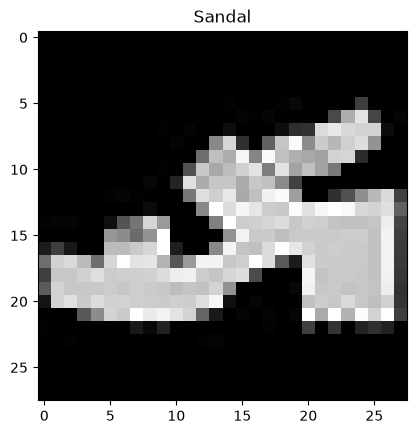

In [ ]:
plt.imshow(test_samples[0].squeeze(), cmap = "gray")
plt.title(class_names[test_labels[0]])

In [ ]:
##  make predictions 

pred_probs = make_predictions(model = model_4, data = test_samples, device = device)
pred_probs[:2]
pred_probs = pred_probs.squeeze(dim=1)  # [9, 1, 10] -> [9, 10]
pred_classes = pred_probs.argmax(dim=1) # [9, 10] -> [9]

In [ ]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [ ]:
test_labels, pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]))

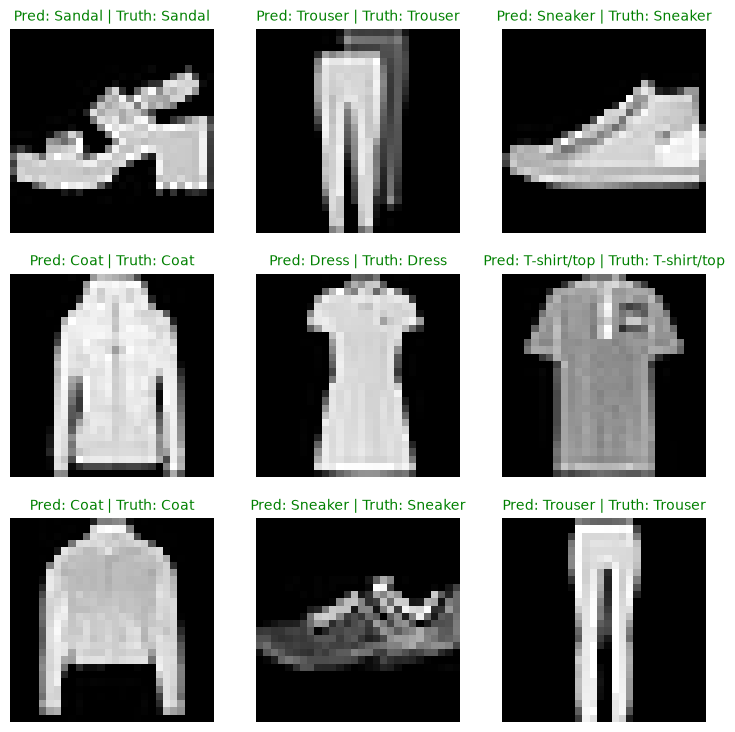

In [ ]:
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]] 

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  
  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);

In [ ]:
from tqdm.auto import tqdm

y_preds = []
model_4.eval()
with tr.inference_mode():
    for x, y in tqdm(test_dataloader):
        x, y = x.to(device), y.to(device)
        y_logit = model_4(x)
        y_pred = tr.softmax(y_logit, dim=1).argmax(dim=1)
        y_preds.append(y_pred.cpu())

y_pred_tensor = tr.cat(y_preds)
y_pred_tensor[:10]

100%|██████████| 313/313 [00:01<00:00, 195.54it/s]


tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [27]:
from mlxtend.plotting import plot_confusion_matrix
from torchmetrics import ConfusionMatrix
mlxtend.__version__, torchmetrics.__version__

NameError: name 'mlxtend' is not defined

In [ ]:
confmat = ConfusionMatrix(num_classes = len(class_names))
confmat_tensor = confmat(preds = y_pred_tensor, target = test_data.targets)
class_names = class_names



NameError: name 'ConfusionMatrix' is not defined